# Cypher Difficulty Classification — 3 Approaches



In [ ]:
#Download datasets (google drive links)
!pip -q install gdown
import os
import gdown

os.makedirs('data', exist_ok=True)

LINK_TEXT2CYPHER = 'https://drive.google.com/uc?id=1h3gsWAYFJspH2VC_qyhKuNODAxEteSFy'
LINK_COMBINED = 'https://drive.google.com/uc?id=17yQ6zObIGYcrUlbLofqpqx1_VThE7MFO'
LINK_CURATED = 'https://drive.google.com/uc?id=1S-fIgHgUZNyCAYw_MsFjh_-y_6KiEE51'

PATH_TEXT2CYPHER = 'data/text2cypher_labeled_levels.csv'
PATH_COMBINED = 'data/combined_text2cypher.csv'
PATH_CURATED = 'data/curated_2500.csv'

gdown.download(LINK_TEXT2CYPHER, PATH_TEXT2CYPHER, quiet=False, fuzzy=True)
gdown.download(LINK_COMBINED, PATH_COMBINED, quiet=False, fuzzy=True)
gdown.download(LINK_CURATED, PATH_CURATED, quiet=False, fuzzy=True)


Downloading...
From: https://drive.google.com/uc?id=1h3gsWAYFJspH2VC_qyhKuNODAxEteSFy
To: /content/data/text2cypher_labeled_levels.csv
100%|██████████| 11.3M/11.3M [00:00<00:00, 104MB/s] 
Downloading...
From: https://drive.google.com/uc?id=17yQ6zObIGYcrUlbLofqpqx1_VThE7MFO
To: /content/data/combined_text2cypher.csv
100%|██████████| 7.08M/7.08M [00:00<00:00, 60.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1S-fIgHgUZNyCAYw_MsFjh_-y_6KiEE51
To: /content/data/curated_2500.csv
100%|██████████| 542k/542k [00:00<00:00, 235MB/s]


'data/curated_2500.csv'

In [ ]:
import random
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch
from torch.optim import AdamW
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
# Configuration
TEXT_COL = 'cypher'
LABEL_COL = 'level'
MODEL_NAME = 'microsoft/codebert-base'
OUTPUT_DIR = 'outputs/codebert-cypher-difficulty'
MAX_LENGTH = 256

TRAIN_RATIO = 0.8
VAL_RATIO = 0.1

EPOCHS = 5
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

SUBSAMPLE = True
SUBSAMPLE_FRAC = 0.2


In [ ]:
# Label mapping
LABEL_ORDER = ["nodeLevel", "1hop", "2hop", "3hop", "hardLevel"]
LABEL2ID = {name: i for i, name in enumerate(LABEL_ORDER)}
ID2LABEL = {i: name for name, i in LABEL2ID.items()}

def normalize_label(label: str) -> str:
    normalized = "".join(ch for ch in str(label).strip().lower() if ch.isalnum())
    mapping = {
        "nodelevel": "nodeLevel",
        "1hop": "1hop",
        "2hop": "2hop",
        "3hop": "3hop",
        "hard": "hardLevel",
        "hardlevel": "hardLevel",
    }
    if normalized not in mapping:
        raise ValueError(f"Unknown label '{label}'. Expected one of: {LABEL_ORDER}")
    return mapping[normalized]


In [ ]:
# Utilities

def build_rows_from_csv(path):
    df = pd.read_csv(path)
    rows = []
    for _, r in df.iterrows():
        text = str(r.get(TEXT_COL, '')).strip()
        if not text:
            continue
        label_name = normalize_label(str(r.get(LABEL_COL, '')))
        rows.append({'text': text, 'label': LABEL2ID[label_name]})
    return rows


def stratified_subsample(rows, frac):
    df = pd.DataFrame(rows)
    df = df.groupby('label', group_keys=False).apply(
        lambda x: x.sample(frac=frac, random_state=SEED)
    ).reset_index(drop=True)
    return df.to_dict('records')


def stratified_split(rows):
    y = np.array([r['label'] for r in rows])
    train_rows, val_test_rows = train_test_split(
        rows, test_size=(1 - TRAIN_RATIO), random_state=SEED, stratify=y, shuffle=True
    )
    val_test_y = np.array([r['label'] for r in val_test_rows])
    val_ratio_rel = VAL_RATIO / (1 - TRAIN_RATIO)
    val_rows, test_rows = train_test_split(
        val_test_rows, test_size=(1 - val_ratio_rel), random_state=SEED, stratify=val_test_y, shuffle=True
    )
    return train_rows, val_rows, test_rows


class CypherDataset(Dataset):
    def __init__(self, rows, tokenizer, max_length):
        self.rows = rows
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        item = self.rows[idx]
        enc = self.tokenizer(
            item['text'],
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels': torch.tensor(item['label'], dtype=torch.long)
        }


def build_loaders(train_rows, val_rows, test_rows, tokenizer):
    train_ds = CypherDataset(train_rows, tokenizer, MAX_LENGTH)
    val_ds = CypherDataset(val_rows, tokenizer, MAX_LENGTH)
    test_ds = CypherDataset(test_rows, tokenizer, MAX_LENGTH)
    return (
        DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True),
        DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False),
        DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False),
    )


def train_one_epoch(model, train_loader, optimizer):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    for batch in train_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=-1).detach().cpu().numpy()
        labels = batch['labels'].detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(train_loader), acc, f1


def eval_one_epoch(model, loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=-1).detach().cpu().numpy()
            labels = batch['labels'].detach().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), acc, f1


def eval_curated_full(model, tokenizer, curated_csv):
    df = pd.read_csv(curated_csv)
    rows = []
    for _, r in df.iterrows():
        text = str(r.get(TEXT_COL, '')).strip()
        if not text:
            continue
        label_name = normalize_label(str(r.get(LABEL_COL, '')))
        rows.append({'text': text, 'label': LABEL2ID[label_name]})
    loader = DataLoader(CypherDataset(rows, tokenizer, MAX_LENGTH), batch_size=BATCH_SIZE, shuffle=False)
    return eval_one_epoch(model, loader)


def eval_hard_metrics(model, tokenizer, curated_csv):
    df = pd.read_csv(curated_csv)
    rows = []
    for _, r in df.iterrows():
        text = str(r.get(TEXT_COL, '')).strip()
        if not text:
            continue
        label_name = normalize_label(str(r.get(LABEL_COL, '')))
        rows.append({'text': text, 'label': LABEL2ID[label_name]})
    loader = DataLoader(CypherDataset(rows, tokenizer, MAX_LENGTH), batch_size=BATCH_SIZE, shuffle=False)
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
            labels = batch['labels'].cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)
    hard_id = LABEL2ID['hardLevel']
    prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, labels=[hard_id], average=None)
    return prec[0], rec[0], f1[0]


## Approach 1

In [ ]:

data= pd.read_csv(PATH_TEXT2CYPHER)
data.head()

,question,cypher,level
0,Which 3 countries have the most entities linke...,MATCH (f:Filing)-[:BENEFITS]->(e:Entity)-[:COU...,hard
1,What are the names of the first 3 organization...,MATCH (o:Organization)-[:HAS_CEO]->(ceo:Person...,1 hop
2,List the names of the games played by streams ...,MATCH (s:Stream)-[:PLAYS]->(g:Game) WHERE s.to...,1 hop
3,For each Article find its abstract and the cou...,MATCH (n:Article) -[:HAS_KEY]->(m:Keyword) WIT...,hard
4,Find the Author for which first_name starts wi...,MATCH (n:Author) WHERE n.first_name STARTS WIT...,node level


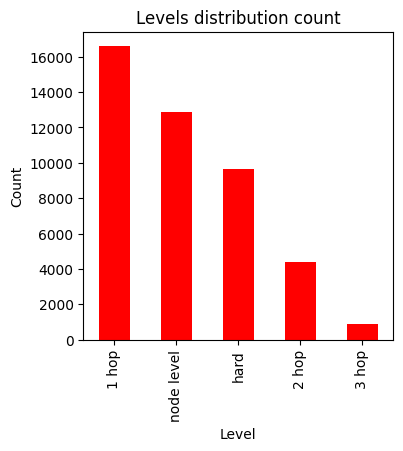

In [ ]:
#Bar plot to visualize the total counts of each level

fig = plt.figure(figsize=(4,4))
data[LABEL_COL].value_counts().plot.bar(color = 'red')
plt.title('Levels distribution count')
plt.xlabel('Level')
plt.ylabel('Count')
plt.show()

In [ ]:
#I create a list of cyphers and normalized labels
rows=[]
for idx, r in data.iterrows():
  text=r[TEXT_COL]
  label_name = normalize_label(str(r[LABEL_COL]))
  rows.append({'text': text, 'label': LABEL2ID[label_name]})

In [ ]:
def normalize_text(s):
    return " ".join(s.split()).strip().lower()

# Build a DataFrame from rows
df = pd.DataFrame(rows)
df["text_norm"] = df["text"].apply(normalize_text)

# If the same text appears with different labels, drop it (ambiguous)
conflicts = df.groupby("text_norm")["label"].nunique()
conflict_texts = set(conflicts[conflicts > 1].index)
df = df[~df["text_norm"].isin(conflict_texts)]

# Deduplicate (keep first)
df = df.drop_duplicates(subset=["text_norm"])

rows = df[["text", "label"]].to_dict("records")


In [ ]:
print(rows[0])


{'text': 'MATCH (f:Filing)-[:BENEFITS]->(e:Entity)-[:COUNTRY]->(c:Country) WITH c.name AS country, COUNT(e) AS entityCount ORDER BY entityCount DESC LIMIT 3 RETURN country, entityCount', 'label': 4}


In [ ]:
# Stratified subsample (manual)
if SUBSAMPLE:
    data2 = pd.DataFrame(rows)
    sampled_parts = []
    for lbl, group in data2.groupby('label'):
        sampled_parts.append(group.sample(frac=SUBSAMPLE_FRAC, random_state=SEED))
    data2 = pd.concat(sampled_parts, ignore_index=True)
    rows = data2.to_dict('records')




In [ ]:
print(rows[0])


{'text': 'MATCH (n:Article) WHERE n.article_id > 1015 OR n.article_id < 1009 RETURN n LIMIT 8', 'label': 0}


In [ ]:


y = np.array([r['label'] for r in rows])

train_rows, val_test_rows = train_test_split(
    rows,
    test_size=(1 - TRAIN_RATIO),
    random_state=SEED,
    stratify=y,
    shuffle=True
)

val_test_y = np.array([r['label'] for r in val_test_rows])
val_ratio_rel = VAL_RATIO / (1 - TRAIN_RATIO)

val_rows, test_rows = train_test_split(
    val_test_rows,
    test_size=(1 - val_ratio_rel),
    random_state=SEED,
    stratify=val_test_y,
    shuffle=True
)



In [ ]:

DEVICE = torch.device('cuda')




In [ ]:
# Dataset class
class CypherDataset(torch.utils.data.Dataset):
    def __init__(self, rows, tokenizer, max_length):
        self.rows = rows
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        item = self.rows[idx]
        enc = self.tokenizer(
            item['text'],
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels': torch.tensor(item['label'], dtype=torch.long)
        }



tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

# Build datasets + loaders
train_ds = CypherDataset(train_rows, tokenizer, MAX_LENGTH)
val_ds = CypherDataset(val_rows, tokenizer, MAX_LENGTH)
test_ds = CypherDataset(test_rows, tokenizer, MAX_LENGTH)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL2ID),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model.to(DEVICE)


optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)





/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Exact overlap check
train_texts = set(r['text'].strip() for r in train_rows)
val_texts = set(r['text'].strip() for r in val_rows)
test_texts = set(r['text'].strip() for r in test_rows)

print("Train ∩ Val:", len(train_texts & val_texts))
print("Train ∩ Test:", len(train_texts & test_texts))
print("Val ∩ Test:", len(val_texts & test_texts))


Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [ ]:
def normalize_text(s):
    return " ".join(s.split()).strip().lower()

train_texts = set(normalize_text(r['text']) for r in train_rows)
val_texts = set(normalize_text(r['text']) for r in val_rows)
test_texts = set(normalize_text(r['text']) for r in test_rows)

print("Train ∩ Val (normalized):", len(train_texts & val_texts))
print("Train ∩ Test (normalized):", len(train_texts & test_texts))
print("Val ∩ Test (normalized):", len(val_texts & test_texts))


Train ∩ Val (normalized): 0
Train ∩ Test (normalized): 0
Val ∩ Test (normalized): 0


In [ ]:
def normalize_text(s):
    return " ".join(s.split()).strip().lower()

train_texts = set(normalize_text(r['text']) for r in train_rows)
val_texts = set(normalize_text(r['text']) for r in val_rows)
test_texts = set(normalize_text(r['text']) for r in test_rows)

print("Train ∩ Val (normalized):", len(train_texts & val_texts))
print("Train ∩ Test (normalized):", len(train_texts & test_texts))
print("Val ∩ Test (normalized):", len(val_texts & test_texts))


Train ∩ Val (normalized): 0
Train ∩ Test (normalized): 0
Val ∩ Test (normalized): 0


Epoch 1/5 | train loss 0.2448 acc 0.9188 f1 0.8434 | val loss 0.0431 acc 0.9903 f1 0.9893
Epoch 2/5 | train loss 0.0278 acc 0.9938 f1 0.9821 | val loss 0.0287 acc 0.9964 f1 0.9963
Epoch 3/5 | train loss 0.0101 acc 0.9977 f1 0.9908 | val loss 0.0299 acc 0.9964 f1 0.9963
Epoch 4/5 | train loss 0.0099 acc 0.9980 f1 0.9960 | val loss 0.0512 acc 0.9891 f1 0.9524
Epoch 5/5 | train loss 0.0129 acc 0.9965 f1 0.9869 | val loss 0.0315 acc 0.9964 f1 0.9963


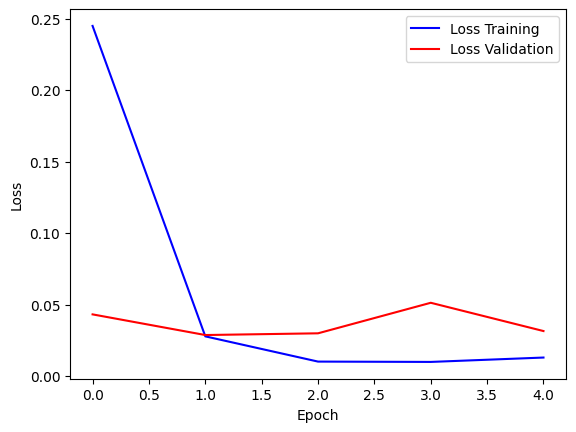

Test loss 0.0032 acc 0.9988 f1 0.9931


In [ ]:


def train_one_epoch():
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for batch in train_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=-1).detach().cpu().numpy()
        labels = batch['labels'].detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(train_loader), acc, f1


def eval_one_epoch(loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=-1).detach().cpu().numpy()
            labels = batch['labels'].detach().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), acc, f1


# Train + collect losses
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss, train_acc, train_f1 = train_one_epoch()
    val_loss, val_acc, val_f1 = eval_one_epoch(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f}")

#Plot losses
plt.plot(range(len(train_losses)), train_losses, c='b', label='Loss Training')
plt.plot(range(len(val_losses)), val_losses, c='r', label='Loss Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

#Test
test_loss, test_acc, test_f1 = eval_one_epoch(test_loader)
print(f"Test loss {test_loss:.4f} acc {test_acc:.4f} f1 {test_f1:.4f}")


In [21]:
# Save after training
model.save_pretrained("codebert_cypher_model1")
tokenizer.save_pretrained("codebert_cypher_model1")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('codebert_cypher_model1/tokenizer_config.json',
 'codebert_cypher_model1/tokenizer.json')

In [22]:
#lod and test on trivial query
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model = AutoModelForSequenceClassification.from_pretrained("codebert_cypher_model1")
tokenizer = AutoTokenizer.from_pretrained("codebert_cypher_model1")
model.eval()

query = "MATCH (n) RETURN n LIMIT 5"
inputs = tokenizer(query, return_tensors="pt", truncation=True, max_length=256)
with torch.no_grad():
    logits = model(**inputs).logits
pred = torch.argmax(logits, dim=-1).item()
print(ID2LABEL[pred])


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

nodeLevel


In [23]:

#test on non trivial query
query =   "MATCH (m:pre_miRNA)-[:is_causal_somatic_mutation_in]->(p) WHERE (p:Phenotype OR (p)-[:subclassof*1..5]->(:Phenotype)) AND p.Label CONTAINS 'Thyroid' RETURN DISTINCT m.Label AS pre_miRNA, p"

inputs = tokenizer(query, return_tensors="pt", truncation=True, max_length=256)
with torch.no_grad():
    logits = model(**inputs).logits
pred = torch.argmax(logits, dim=-1).item()
print(ID2LABEL[pred])

2hop


the output  '2hop' is not correct, the query is hardlevel

In [27]:
# Curated evaluation (all levels)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(DEVICE)


df_cur = pd.read_csv(PATH_CURATED)

curated_rows = []
for _, row in df_cur.iterrows():
    text = str(row.get('cypher', '')).strip()
    if not text:
        continue
    label_name = normalize_label(str(row.get('level', '')))
    curated_rows.append({'text': text, 'label': LABEL2ID[label_name]})

curated_ds = CypherDataset(curated_rows, tokenizer, MAX_LENGTH)
curated_loader = torch.utils.data.DataLoader(curated_ds, batch_size=BATCH_SIZE, shuffle=False)

# eval_one_epoch already moves batch to DEVICE
cur_loss, cur_acc, cur_f1 = eval_one_epoch(curated_loader)
print(f"Curated set -> loss {cur_loss:.4f} acc {cur_acc:.4f} f1 {cur_f1:.4f}")


Curated set -> loss 0.6441 acc 0.9216 f1 0.9199


In [28]:
# Curated evaluation (hard level)


# Load curated data
df_cur = pd.read_csv(PATH_CURATED)

curated_rows = []
for _, row in df_cur.iterrows():
    text = str(row.get('cypher', '')).strip()
    if not text:
        continue
    label_name = normalize_label(str(row.get('level', '')))
    curated_rows.append({'text': text, 'label': LABEL2ID[label_name]})

curated_ds = CypherDataset(curated_rows, tokenizer, MAX_LENGTH)
curated_loader = torch.utils.data.DataLoader(curated_ds, batch_size=BATCH_SIZE, shuffle=False)

# Predict on full curated set
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in curated_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
        labels = batch['labels'].cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

hard_id = LABEL2ID['hardLevel']

# Precision/Recall/F1 for hardLevel only
prec, rec, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, labels=[hard_id], average=None
)

print(f"HardLevel precision: {prec[0]:.4f}")
print(f"HardLevel recall:    {rec[0]:.4f}")
print(f"HardLevel F1:        {f1[0]:.4f}")




HardLevel precision: 0.9868
HardLevel recall:    0.7460
HardLevel F1:        0.8497


## Approach 2

In [29]:

data= pd.read_csv(PATH_COMBINED)
data.head()

,cypher,level
0,MATCH (f:Filing)-[:BENEFITS]->(e:Entity)-[:COU...,hard
1,MATCH (o:Organization)-[:HAS_CEO]->(ceo:Person...,1 hop
2,MATCH (s:Stream)-[:PLAYS]->(g:Game) WHERE s.to...,1 hop
3,MATCH (n:Article) -[:HAS_KEY]->(m:Keyword) WIT...,hard
4,MATCH (n:Author) WHERE n.first_name STARTS WIT...,node level


In [30]:
#I create a list of cyphers and normalized labels
rows=[]
for idx, r in data.iterrows():
  text=r[TEXT_COL]
  label_name = normalize_label(str(r[LABEL_COL]))
  rows.append({'text': text, 'label': LABEL2ID[label_name]})

In [31]:
def normalize_text(s):
    return " ".join(s.split()).strip().lower()

# Build a DataFrame from rows
df = pd.DataFrame(rows)
df["text_norm"] = df["text"].apply(normalize_text)

# If the same text appears with different labels, drop it (ambiguous)
conflicts = df.groupby("text_norm")["label"].nunique()
conflict_texts = set(conflicts[conflicts > 1].index)
df = df[~df["text_norm"].isin(conflict_texts)]

# Deduplicate (keep first)
df = df.drop_duplicates(subset=["text_norm"])

rows = df[["text", "label"]].to_dict("records")


In [32]:
print(rows[0])


{'text': 'MATCH (f:Filing)-[:BENEFITS]->(e:Entity)-[:COUNTRY]->(c:Country) WITH c.name AS country, COUNT(e) AS entityCount ORDER BY entityCount DESC LIMIT 3 RETURN country, entityCount', 'label': 4}


In [33]:
# Stratified subsample (manual)
if SUBSAMPLE:
    data2 = pd.DataFrame(rows)
    sampled_parts = []
    for lbl, group in data2.groupby('label'):
        sampled_parts.append(group.sample(frac=SUBSAMPLE_FRAC, random_state=SEED))
    data2 = pd.concat(sampled_parts, ignore_index=True)
    rows = data2.to_dict('records')




In [34]:
print(rows[0])


{'text': "MATCH (b:Business) WHERE b.city = 'San Mateo' RETURN b.name, b.address, b.city, b.state, b.businessId LIMIT 3", 'label': 0}


In [35]:
#Since the dataset comes from merged sources, I shuffle to avoid blocks from the same source ending up in a single split.

y = np.array([r['label'] for r in rows])

train_rows, val_test_rows = train_test_split(
    rows,
    test_size=(1 - TRAIN_RATIO),
    random_state=SEED,
    stratify=y,
    shuffle=True
)

val_test_y = np.array([r['label'] for r in val_test_rows])
val_ratio_rel = VAL_RATIO / (1 - TRAIN_RATIO)

val_rows, test_rows = train_test_split(
    val_test_rows,
    test_size=(1 - val_ratio_rel),
    random_state=SEED,
    stratify=val_test_y,
    shuffle=True
)



In [36]:

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(DEVICE)





RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [37]:
# Dataset class
class CypherDataset(torch.utils.data.Dataset):
    def __init__(self, rows, tokenizer, max_length):
        self.rows = rows
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        item = self.rows[idx]
        enc = self.tokenizer(
            item['text'],
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels': torch.tensor(item['label'], dtype=torch.long)
        }



tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

# Build datasets + loaders
train_ds = CypherDataset(train_rows, tokenizer, MAX_LENGTH)
val_ds = CypherDataset(val_rows, tokenizer, MAX_LENGTH)
test_ds = CypherDataset(test_rows, tokenizer, MAX_LENGTH)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL2ID),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model.to(DEVICE)


optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)





Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/5 | train loss 0.2551 acc 0.9145 f1 0.8513 | val loss 0.0312 acc 0.9943 f1 0.9861
Epoch 2/5 | train loss 0.0450 acc 0.9899 f1 0.9756 | val loss 0.0254 acc 0.9932 f1 0.9800
Epoch 3/5 | train loss 0.0301 acc 0.9939 f1 0.9853 | val loss 0.0433 acc 0.9886 f1 0.9658
Epoch 4/5 | train loss 0.0222 acc 0.9951 f1 0.9897 | val loss 0.0279 acc 0.9932 f1 0.9780
Epoch 5/5 | train loss 0.0239 acc 0.9947 f1 0.9866 | val loss 0.0260 acc 0.9932 f1 0.9780


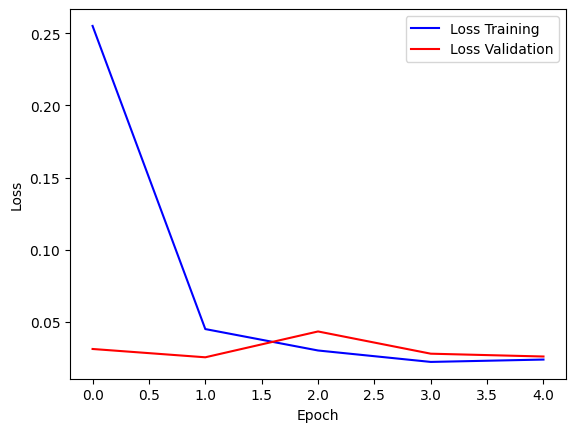

Test loss 0.0190 acc 0.9954 f1 0.9846


In [38]:


def train_one_epoch():
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for batch in train_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=-1).detach().cpu().numpy()
        labels = batch['labels'].detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(train_loader), acc, f1


def eval_one_epoch(loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=-1).detach().cpu().numpy()
            labels = batch['labels'].detach().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), acc, f1


# ---- Train + collect losses ----
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss, train_acc, train_f1 = train_one_epoch()
    val_loss, val_acc, val_f1 = eval_one_epoch(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f}")

# Plot losses
plt.plot(range(len(train_losses)), train_losses, c='b', label='Loss Training')
plt.plot(range(len(val_losses)), val_losses, c='r', label='Loss Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Test
test_loss, test_acc, test_f1 = eval_one_epoch(test_loader)
print(f"Test loss {test_loss:.4f} acc {test_acc:.4f} f1 {test_f1:.4f}")


In [39]:
# Save after training
model.save_pretrained("codebert_cypher_model2")
tokenizer.save_pretrained("codebert_cypher_model2")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('codebert_cypher_model2/tokenizer_config.json',
 'codebert_cypher_model2/tokenizer.json')

In [40]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model = AutoModelForSequenceClassification.from_pretrained("codebert_cypher_model2")
tokenizer = AutoTokenizer.from_pretrained("codebert_cypher_model2")
model.eval()

query = "MATCH (n) RETURN n LIMIT 5"
inputs = tokenizer(query, return_tensors="pt", truncation=True, max_length=256)
with torch.no_grad():
    logits = model(**inputs).logits
pred = torch.argmax(logits, dim=-1).item()
print(ID2LABEL[pred])


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

nodeLevel


In [41]:


query =   "MATCH (m:pre_miRNA)-[:is_causal_somatic_mutation_in]->(p) WHERE (p:Phenotype OR (p)-[:subclassof*1..5]->(:Phenotype)) AND p.Label CONTAINS 'Thyroid' RETURN DISTINCT m.Label AS pre_miRNA, p"




inputs = tokenizer(query, return_tensors="pt", truncation=True, max_length=256)
with torch.no_grad():
    logits = model(**inputs).logits
pred = torch.argmax(logits, dim=-1).item()
print(ID2LABEL[pred])


hardLevel


the output is correct, the query is hard level

In [42]:
# Curated evaluation (all levels)
DEVICE = torch.device('cuda')
model.to(DEVICE)

df_cur = pd.read_csv(PATH_CURATED)

curated_rows = []
for _, row in df_cur.iterrows():
    text = str(row.get('cypher', '')).strip()
    if not text:
        continue
    label_name = normalize_label(str(row.get('level', '')))
    curated_rows.append({'text': text, 'label': LABEL2ID[label_name]})

curated_ds = CypherDataset(curated_rows, tokenizer, MAX_LENGTH)
curated_loader = torch.utils.data.DataLoader(curated_ds, batch_size=BATCH_SIZE, shuffle=False)

# eval_one_epoch already moves batch to DEVICE
cur_loss, cur_acc, cur_f1 = eval_one_epoch(curated_loader)
print(f"Curated set -> loss {cur_loss:.4f} acc {cur_acc:.4f} f1 {cur_f1:.4f}")


Curated set -> loss 0.2029 acc 0.9484 f1 0.9483


In [43]:
# Curated evaluation (hard level)


# Load curated data
df_cur = pd.read_csv(PATH_CURATED)

curated_rows = []
for _, row in df_cur.iterrows():
    text = str(row.get('cypher', '')).strip()
    if not text:
        continue
    label_name = normalize_label(str(row.get('level', '')))
    curated_rows.append({'text': text, 'label': LABEL2ID[label_name]})

curated_ds = CypherDataset(curated_rows, tokenizer, MAX_LENGTH)
curated_loader = torch.utils.data.DataLoader(curated_ds, batch_size=BATCH_SIZE, shuffle=False)

# Predict on full curated set
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in curated_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
        labels = batch['labels'].cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

hard_id = LABEL2ID['hardLevel']

# Precision/Recall/F1 for hardLevel only
prec, rec, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, labels=[hard_id], average=None
)

print(f"HardLevel precision: {prec[0]:.4f}")
print(f"HardLevel recall:    {rec[0]:.4f}")
print(f"HardLevel F1:        {f1[0]:.4f}")



HardLevel precision: 0.9933
HardLevel recall:    0.8940
HardLevel F1:        0.9411


## Approach 3

In [44]:

data= pd.read_csv(PATH_TEXT2CYPHER)


In [45]:
#I create a list of cyphers and normalized labels
rows=[]
for idx, r in data.iterrows():
  text=r[TEXT_COL]
  label_name = normalize_label(str(r[LABEL_COL]))
  rows.append({'text': text, 'label': LABEL2ID[label_name]})

In [46]:
def normalize_text(s):
    return " ".join(s.split()).strip().lower()

# Build a DataFrame from rows
df = pd.DataFrame(rows)
df["text_norm"] = df["text"].apply(normalize_text)

# If the same text appears with different labels, drop it (ambiguous)
conflicts = df.groupby("text_norm")["label"].nunique()
conflict_texts = set(conflicts[conflicts > 1].index)
df = df[~df["text_norm"].isin(conflict_texts)]

# Deduplicate (keep first)
df = df.drop_duplicates(subset=["text_norm"])

rows = df[["text", "label"]].to_dict("records")


In [48]:
# Stratified subsample (manual)
if SUBSAMPLE:
    data2 = pd.DataFrame(rows)
    sampled_parts = []
    for lbl, group in data2.groupby('label'):
        sampled_parts.append(group.sample(frac=SUBSAMPLE_FRAC, random_state=SEED))
    data2 = pd.concat(sampled_parts, ignore_index=True)
    rows = data2.to_dict('records')




In [49]:


y = np.array([r['label'] for r in rows])

train_rows, val_test_rows = train_test_split(
    rows,
    test_size=(1 - TRAIN_RATIO),
    random_state=SEED,
    stratify=y,
    shuffle=True
)

val_test_y = np.array([r['label'] for r in val_test_rows])
val_ratio_rel = VAL_RATIO / (1 - TRAIN_RATIO)

val_rows, test_rows = train_test_split(
    val_test_rows,
    test_size=(1 - val_ratio_rel),
    random_state=SEED,
    stratify=val_test_y,
    shuffle=True
)



In [50]:

DEVICE = torch.device('cuda')




In [51]:
# Dataset class
class CypherDataset(torch.utils.data.Dataset):
    def __init__(self, rows, tokenizer, max_length):
        self.rows = rows
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        item = self.rows[idx]
        enc = self.tokenizer(
            item['text'],
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels': torch.tensor(item['label'], dtype=torch.long)
        }



tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

# Build datasets + loaders
train_ds = CypherDataset(train_rows, tokenizer, MAX_LENGTH)
val_ds = CypherDataset(val_rows, tokenizer, MAX_LENGTH)
test_ds = CypherDataset(test_rows, tokenizer, MAX_LENGTH)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL2ID),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model.to(DEVICE)


optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)





Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/5 | train loss 0.2521 acc 0.9156 f1 0.8402 | val loss 0.0713 acc 0.9734 f1 0.9078
Epoch 2/5 | train loss 0.0309 acc 0.9917 f1 0.9696 | val loss 0.0362 acc 0.9927 f1 0.9807
Epoch 3/5 | train loss 0.0167 acc 0.9958 f1 0.9830 | val loss 0.0279 acc 0.9952 f1 0.9947
Epoch 4/5 | train loss 0.0173 acc 0.9955 f1 0.9836 | val loss 0.0255 acc 0.9940 f1 0.9939
Epoch 5/5 | train loss 0.0103 acc 0.9970 f1 0.9870 | val loss 0.0153 acc 0.9964 f1 0.9962


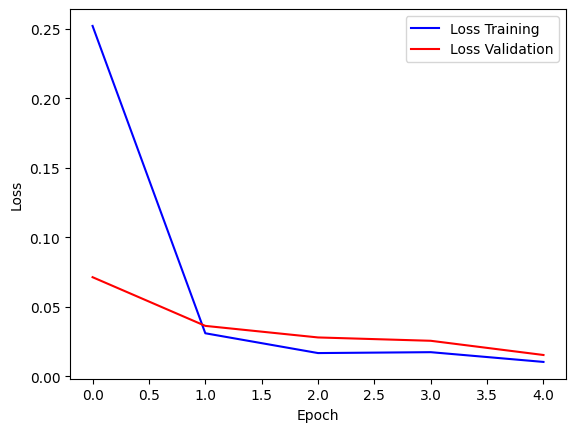

Test loss 0.0011 acc 1.0000 f1 1.0000


In [52]:


def train_one_epoch():
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for batch in train_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=-1).detach().cpu().numpy()
        labels = batch['labels'].detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(train_loader), acc, f1


def eval_one_epoch(loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=-1).detach().cpu().numpy()
            labels = batch['labels'].detach().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), acc, f1


# Train + collect losses
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss, train_acc, train_f1 = train_one_epoch()
    val_loss, val_acc, val_f1 = eval_one_epoch(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f}")

# Plot losses
plt.plot(range(len(train_losses)), train_losses, c='b', label='Loss Training')
plt.plot(range(len(val_losses)), val_losses, c='r', label='Loss Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Test
test_loss, test_acc, test_f1 = eval_one_epoch(test_loader)
print(f"Test loss {test_loss:.4f} acc {test_acc:.4f} f1 {test_f1:.4f}")


In [53]:
# Save after training
model.save_pretrained("codebert_cypher_model3")
tokenizer.save_pretrained("codebert_cypher_model3")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('codebert_cypher_model3/tokenizer_config.json',
 'codebert_cypher_model3/tokenizer.json')

In [54]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model = AutoModelForSequenceClassification.from_pretrained("codebert_cypher_model3")
tokenizer = AutoTokenizer.from_pretrained("codebert_cypher_model3")
model.eval()

query = "MATCH (n) RETURN n LIMIT 5"
inputs = tokenizer(query, return_tensors="pt", truncation=True, max_length=256)
with torch.no_grad():
    logits = model(**inputs).logits
pred = torch.argmax(logits, dim=-1).item()
print(ID2LABEL[pred])


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

nodeLevel


In [55]:


query =   "MATCH (m:pre_miRNA)-[:is_causal_somatic_mutation_in]->(p) WHERE (p:Phenotype OR (p)-[:subclassof*1..5]->(:Phenotype)) AND p.Label CONTAINS 'Thyroid' RETURN DISTINCT m.Label AS pre_miRNA, p"




inputs = tokenizer(query, return_tensors="pt", truncation=True, max_length=256)
with torch.no_grad():
    logits = model(**inputs).logits
pred = torch.argmax(logits, dim=-1).item()
print(ID2LABEL[pred])


2hop


the output '2hop' is not correct, the query is hardlevel

In [56]:
#  Curated evaluation (single block)


DEVICE = torch.device('cuda')
model.to(DEVICE)


df_cur = pd.read_csv(PATH_CURATED)
curated_rows = []
for _, row in df_cur.iterrows():
    text = str(row.get('cypher', '')).strip()
    if not text:
        continue
    label_name = normalize_label(str(row.get('level', '')))
    curated_rows.append({'text': text, 'label': LABEL2ID[label_name]})

curated_ds = CypherDataset(curated_rows, tokenizer, MAX_LENGTH)
curated_loader = torch.utils.data.DataLoader(curated_ds, batch_size=BATCH_SIZE, shuffle=False)

# eval_one_epoch already moves batch to DEVICE
cur_loss, cur_acc, cur_f1 = eval_one_epoch(curated_loader)
print(f"Curated set -> loss {cur_loss:.4f} acc {cur_acc:.4f} f1 {cur_f1:.4f}")


Curated set -> loss 0.6462 acc 0.9220 f1 0.9200


In [57]:


DEVICE = torch.device('cuda')
model.to(DEVICE)



# Load curated data
df_cur = pd.read_csv(PATH_CURATED)
curated_rows = []
for _, row in df_cur.iterrows():
    text = str(row.get('cypher', '')).strip()
    if not text:
        continue
    label_name = normalize_label(str(row.get('level', '')))
    curated_rows.append({'text': text, 'label': LABEL2ID[label_name]})

curated_ds = CypherDataset(curated_rows, tokenizer, MAX_LENGTH)
curated_loader = torch.utils.data.DataLoader(curated_ds, batch_size=BATCH_SIZE, shuffle=False)

# Predict on full curated set
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in curated_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
        labels = batch['labels'].cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

hard_id = LABEL2ID['hardLevel']

# Precision/Recall/F1 for hardLevel only
prec, rec, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, labels=[hard_id], average=None
)

print(f"HardLevel precision: {prec[0]:.4f}")
print(f"HardLevel recall:    {rec[0]:.4f}")
print(f"HardLevel F1:        {f1[0]:.4f}")



HardLevel precision: 0.9868
HardLevel recall:    0.7460
HardLevel F1:        0.8497


In [58]:
# Second training on curated dataset
FINE_TUNE_EPOCHS = 3
FINE_TUNE_LR = 5e-6



import pandas as pd
import torch
from torch.optim import AdamW

#if not Path(PATH_CURATED).exists():
    #raise FileNotFoundError(PATH_CURATED)

df_cur = pd.read_csv(PATH_CURATED)
curated_rows = []
for _, row in df_cur.iterrows():
    text = str(row.get('cypher', '')).strip()
    if not text:
        continue
    label_name = normalize_label(str(row.get('level', '')))
    curated_rows.append({'text': text, 'label': LABEL2ID[label_name]})

curated_ds = CypherDataset(curated_rows, tokenizer, MAX_LENGTH)
curated_loader = torch.utils.data.DataLoader(curated_ds, batch_size=BATCH_SIZE, shuffle=True)

# New optimizer for fine-tuning
optimizer_ft = AdamW(model.parameters(), lr=FINE_TUNE_LR, weight_decay=WEIGHT_DECAY)

for epoch in range(FINE_TUNE_EPOCHS):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for batch in curated_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss

        optimizer_ft.zero_grad()
        loss.backward()
        optimizer_ft.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=-1).detach().cpu().numpy()
        labels = batch['labels'].detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"Fine-tune epoch {epoch+1}/{FINE_TUNE_EPOCHS} | loss {total_loss/len(curated_loader):.4f} acc {acc:.4f} f1 {f1:.4f}")


Fine-tune epoch 1/3 | loss 0.2825 acc 0.9384 f1 0.9381
Fine-tune epoch 2/3 | loss 0.1893 acc 0.9504 f1 0.9504
Fine-tune epoch 3/3 | loss 0.1675 acc 0.9568 f1 0.9568


In [59]:
# Save after training
model.save_pretrained("codebert_cypher_model4")
tokenizer.save_pretrained("codebert_cypher_model4")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('codebert_cypher_model4/tokenizer_config.json',
 'codebert_cypher_model4/tokenizer.json')

In [60]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model = AutoModelForSequenceClassification.from_pretrained("codebert_cypher_model4")
tokenizer = AutoTokenizer.from_pretrained("codebert_cypher_model4")
model.eval()

query = "MATCH (n) RETURN n LIMIT 5"
inputs = tokenizer(query, return_tensors="pt", truncation=True, max_length=256)
with torch.no_grad():
    logits = model(**inputs).logits
pred = torch.argmax(logits, dim=-1).item()
print(ID2LABEL[pred])


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

nodeLevel


the output is correct, the query is hard level

In [61]:


query =   "MATCH (m:pre_miRNA)-[:is_causal_somatic_mutation_in]->(p) WHERE (p:Phenotype OR (p)-[:subclassof*1..5]->(:Phenotype)) AND p.Label CONTAINS 'Thyroid' RETURN DISTINCT m.Label AS pre_miRNA, p"

inputs = tokenizer(query, return_tensors="pt", truncation=True, max_length=256)
with torch.no_grad():
    logits = model(**inputs).logits
pred = torch.argmax(logits, dim=-1).item()
print(ID2LABEL[pred])


hardLevel


the output 'hardlevel' is correct

In [62]:


DEVICE = torch.device('cuda')
model.to(DEVICE)



# Load curated data
df_cur = pd.read_csv(PATH_CURATED)
curated_rows = []
for _, row in df_cur.iterrows():
    text = str(row.get('cypher', '')).strip()
    if not text:
        continue
    label_name = normalize_label(str(row.get('level', '')))
    curated_rows.append({'text': text, 'label': LABEL2ID[label_name]})

curated_ds = CypherDataset(curated_rows, tokenizer, MAX_LENGTH)
curated_loader = torch.utils.data.DataLoader(curated_ds, batch_size=BATCH_SIZE, shuffle=False)

# Predict on full curated set
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in curated_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
        labels = batch['labels'].cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

hard_id = LABEL2ID['hardLevel']

# Precision/Recall/F1 for hardLevel only
prec, rec, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, labels=[hard_id], average=None
)

print(f"HardLevel precision: {prec[0]:.4f}")
print(f"HardLevel recall:    {rec[0]:.4f}")
print(f"HardLevel F1:        {f1[0]:.4f}")



HardLevel precision: 0.9897
HardLevel recall:    0.9580
HardLevel F1:        0.9736
